# Projeto Prático - Classificação Binária com MLP (Check Point 2)

*Turma* 2CCPS
**Julia Yamazaki** - **RM568438**

## Contexto

Este notebook apresenta o fluxo completo de preparação de dados, treinamento e avaliação de Redes Neurais MLP para um problema de classificação binária focado em cibersegurança (detecção de tráfego malicioso vs. benigno).

- Fonte da Base de Dados:
A base utilizada é a Cybersecurity Threat Detection Dataset, extraída originalmente da plataforma Kaggle.

- Link para a fonte original: Cybersecurity Threat Detection Dataset (Kaggle)

- Arquivo local carregado neste projeto: cybersecurity.csv


In [13]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('cybersecurity.csv')

## Análise Exploratória dos Dados (EDA)
Exploração inicial para entender distribuições, dados ausentes e desbalanceamento do target. A classe positiva (1) representa tráfego malicioso (ataque) e a classe negativa (0) representa tráfego benigno.

In [15]:
print("--- Dimensões da Base ---")
print(f"Amostras: {df.shape[0]} | Variáveis: {df.shape[1]}")

print("\n--- Valores Ausentes ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n--- Distribuição da Variável Target (label) ---")
print(df['label'].value_counts())
print("\nDesbalanceamento (%):")
print(df['label'].value_counts(normalize=True) * 100)

print("\n--- Duplicatas ---")
print(df.duplicated().sum())

print("\n--- Estatísticas Descritivas ---")
display(df.describe())

--- Dimensões da Base ---
Amostras: 10000 | Variáveis: 13

--- Valores Ausentes ---
url    3232
dtype: int64

--- Distribuição da Variável Target (label) ---
label
0    9600
1     400
Name: count, dtype: int64

Desbalanceamento (%):
label
0    96.0
1     4.0
Name: proportion, dtype: float64

--- Duplicatas ---
0

--- Estatísticas Descritivas ---


,src_port,dst_port,bytes_sent,bytes_received,label
count,10000.000000,10000.000000,1.000000e+04,1.000000e+04,10000.000000
mean,27052.223700,2027.280500,1.412572e+05,2.620883e+05,0.040000
std,20978.783832,6769.141395,2.128140e+06,3.767695e+06,0.195969
min,21.000000,5.000000,1.700000e+01,3.000000e+00,0.000000
25%,6092.250000,25.000000,7.148250e+03,1.096075e+04,0.000000
50%,25431.500000,443.000000,2.181550e+04,3.747300e+04,0.000000
75%,45215.750000,1433.000000,6.509525e+04,1.213795e+05,0.000000
max,65524.000000,65491.000000,1.391704e+08,2.914830e+08,1.000000


## Tratamento dos Dados
Justificativas das decisões:
- **Data Leakage:** A coluna `attack_type` será removida, pois ela descreve o gabarito do ataque e causaria vazamento direto.
- **Alta Cardinalidade / Memorização:** Colunas de identificação e metadados densos (`timestamp`, `src_ip`, `dst_ip`, `url`, `user_agent`) serão removidas para evitar que a rede neural apenas memorize eventos específicos em vez de aprender padrões comportamentais de rede.

In [16]:
# Remoção de features que causam leakage ou não agregam generalização à MLP
colunas_para_remover = ['attack_type', 'timestamp', 'src_ip', 'dst_ip', 'url', 'user_agent']
df_tratado = df.drop(columns=colunas_para_remover)

# Separação em X (features) e y (target)
X = df_tratado.drop(columns=['label'])
y = df_tratado['label']

print("Features utilizadas:", X.columns.tolist())

Features utilizadas: ['src_port', 'dst_port', 'protocol', 'bytes_sent', 'bytes_received', 'is_internal_traffic']


## Pré-processamento e Divisão dos Dados
A divisão será estratificada para preservar os 4% da classe positiva. O fluxo é:
1. Treino (70%), Validação (15%) e Teste (15%).
2. Configuração do `ColumnTransformer`: `StandardScaler` nas variáveis numéricas e `OneHotEncoder` nas categóricas.
3. Ajuste (fit) APENAS no treino, aplicando a transformação na validação e teste.

In [17]:
# Primeira divisão: 70% Treino, 30% Temporário (Validação + Teste)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Segunda divisão: 15% Validação, 15% Teste a partir do temporário
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Definição de colunas numéricas e categóricas
num_cols = ['src_port', 'dst_port', 'bytes_sent', 'bytes_received']
cat_cols = ['protocol', 'is_internal_traffic']

# Pipeline de Transformação
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

# Fit apenas no treino para evitar Leakage
X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

print(f"Treino: {X_train_t.shape} | Validação: {X_val_t.shape} | Teste: {X_test_t.shape}")

Treino: (7000, 9) | Validação: (1500, 9) | Teste: (1500, 9)


## Construção e Treinamento das MLPs
Conforme o plano mínimo, realizaremos os 7 experimentos controlados para avaliar o impacto da largura, profundidade e função de ativação. Mantemos taxa de aprendizado, épocas e semente (random_state) fixas para comparação justa.

In [18]:
# Definição dos experimentos
experimentos = [
    {"id": "E1", "camadas": (16,), "ativacao": "relu", "desc": "Ref. (1x16, ReLU)"},
    {"id": "E2", "camadas": (32,), "ativacao": "relu", "desc": "Largura (1x32, ReLU)"},
    {"id": "E3", "camadas": (64,), "ativacao": "relu", "desc": "Largura (1x64, ReLU)"},
    {"id": "E4", "camadas": (32, 16), "ativacao": "relu", "desc": "Profund. (2 cam., ReLU)"},
    {"id": "E5", "camadas": (64, 32, 16), "ativacao": "relu", "desc": "Profund. (3 cam., ReLU)"},
    {"id": "E6", "camadas": (32,), "ativacao": "tanh", "desc": "Ativ. (1x32, Tanh)"},
    {"id": "E7", "camadas": (32,), "ativacao": "logistic", "desc": "Ativ. (1x32, Sigmoid)"}
]

resultados = []
modelos_salvos = {}

print("Iniciando treinamento...\n")

for exp in experimentos:
    # Configurando o modelo (saída sempred Sigmoid implicitamente no binary classification, otimizador Adam)
    mlp = MLPClassifier(
        hidden_layer_sizes=exp["camadas"],
        activation=exp["ativacao"],
        max_iter=100,
        random_state=42,
        learning_rate_init=0.001
    )

    # Treinamento
    mlp.fit(X_train_t, y_train)
    modelos_salvos[exp["id"]] = mlp

    # Previsões na validação
    y_val_pred = mlp.predict(X_val_t)
    y_val_prob = mlp.predict_proba(X_val_t)[:, 1]

    # Métricas
    val_loss_val = log_loss(y_val, y_val_prob)
    acc = accuracy_score(y_val, y_val_pred)
    prec = precision_score(y_val, y_val_pred, zero_division=0)
    rec = recall_score(y_val, y_val_pred, zero_division=0)
    f1 = f1_score(y_val, y_val_pred, zero_division=0)

    resultados.append({
        "ID": exp["id"],
        "Camadas": str(exp["camadas"]),
        "Ativação": exp["ativacao"],
        "Loss val.": round(val_loss_val, 4),
        "Acurácia": round(acc, 4),
        "Precisão": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4)
    })
    print(f"[{exp['id']}] Concluído.")

Iniciando treinamento...

[E1] Concluído.
[E2] Concluído.
[E3] Concluído.
[E4] Concluído.
[E5] Concluído.
[E6] Concluído.
[E7] Concluído.


## Comparação dos Resultados
Tabela consolidada com o desempenho de todas as arquiteturas avaliadas no conjunto de validação. Devido ao desbalanceamento, a métrica prioritária é o Recall (capacidade de detectar o ataque) aliada ao F1-Score (equilíbrio geral na classe minoritária).

In [19]:
df_resultados = pd.DataFrame(resultados)
display(df_resultados)

,ID,Camadas,Ativação,Loss val.,Acurácia,Precisão,Recall,F1
0,E1,"(16,)",relu,0.1619,0.9600,0.0000,0.0000,0.0000
1,E2,"(32,)",relu,0.1617,0.9600,0.5000,0.0167,0.0323
2,E3,"(64,)",relu,0.1614,0.9587,0.2500,0.0167,0.0312
3,E4,"(32, 16)",relu,0.1611,0.9593,0.3333,0.0167,0.0317
4,E5,"(64, 32, 16)",relu,0.1644,0.9580,0.2000,0.0167,0.0308
5,E6,"(32,)",tanh,0.1634,0.9600,0.0000,0.0000,0.0000
6,E7,"(32,)",logistic,0.1638,0.9600,0.0000,0.0000,0.0000


## Avaliação Final no Conjunto de Teste
A avaliação final será feita com base no modelo que apresentou melhor equilíbrio de detecção da classe minoritária sem overfitting excessivo na tabela de validação.

--- Desempenho Final no Conjunto de Teste (Modelo E2) ---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1440
           1       1.00      0.03      0.06        60

    accuracy                           0.96      1500
   macro avg       0.98      0.52      0.52      1500
weighted avg       0.96      0.96      0.94      1500

Matriz de Confusão [E7]:
[[1440    0]
 [  60    0]]



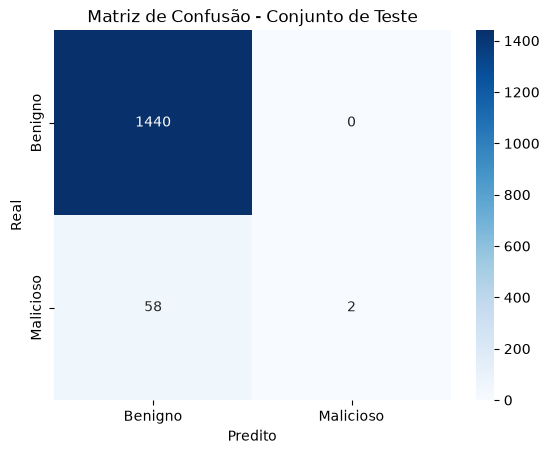

In [21]:
# Ajuste aqui o ID do modelo que apresentou o melhor F1/Recall na sua tabela. Ex: 'E4'
melhor_modelo_id = 'E2' # Alterar mediante resultado da tabela acima
melhor_mlp = modelos_salvos[melhor_modelo_id]

# Previsão no TESTE
y_test_pred = melhor_mlp.predict(X_test_t)

print(f"--- Desempenho Final no Conjunto de Teste (Modelo {melhor_modelo_id}) ---")
print(classification_report(y_test, y_test_pred))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benigno', 'Malicioso'],
            yticklabels=['Benigno', 'Malicioso'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Conjunto de Teste')

cm_val = confusion_matrix(y_val, y_val_pred)
print(f"Matriz de Confusão [{exp['id']}]:\n{cm_val}\n")

plt.show()